# baseline

將`關鍵字`比對換成`向量相似度`比對。

> 請將目前使用關鍵字比對的 route_by_query，改為使用向量相似度進行分類，並設一個合理的相似度門檻，根據檢索結果的分數判斷是否走 RAG 流程。  
例如用向量相似度及自訂 threshold 決定要不要分到 retriever。

> Hint：similarity_search_with_score(...)  
可參考去年的讀書會 R4：向量資料庫的基本操作

In [ ]:
!pip install -q langchain langgraph transformers bitsandbytes langchain-huggingface langchain-community chromadb

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline

# 使用 4-bit 量化模型
model_id = "MediaTek-Research/Breeze-7B-Instruct-v1_0"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    llm_int8_threshold=6.0,
)

# 載入 tokenizer 與 4-bit 模型
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quant_config,
    trust_remote_code=True
)

In [ ]:
from langchain_core.documents import Document
from langchain.vectorstores import Chroma
from langchain.embeddings import HuggingFaceEmbeddings


In [ ]:
from typing_extensions import TypedDict, List
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


In [ ]:
docs_text = """
火影代數	姓名	師傅	徒弟
初代	千手柱間	無明確記載	猿飛日斬、水戶門炎、轉寢小春
二代	千手扉間	千手柱間（兄長）	猿飛日斬、志村團藏、宇智波鏡等
三代	猿飛日斬	千手柱間、千手扉間	自來也、大蛇丸、千手綱手（傳說三忍）
四代	波風湊	自來也	旗木卡卡西、宇智波帶土、野原琳
五代	千手綱手	猿飛日斬	春野櫻、志乃等（主要為春野櫻）
六代	旗木卡卡西	波風湊	漩渦鳴人、宇智波佐助、春野櫻（第七班）
七代	漩渦鳴人	自來也、旗木卡卡西	木葉丸等（主要為木葉丸）
"""

In [ ]:
docs = [Document(page_content=txt.strip()) for txt in docs_text.strip().split("\n\n")]

embedding_model = HuggingFaceEmbeddings(
    model_name="infgrad/stella-base-zh-v3-1792d",
    encode_kwargs={"normalize_embeddings": True}
)

persist_path = "document_store"
collection_name = "naruto_collection"
vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory=persist_path,
    collection_name=collection_name
)

In [ ]:
generator = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.4,
    return_full_text=False # 僅返回生成的回應內容
)

Device set to use cuda:0


In [ ]:
# 定義 LangGraph 的 State 結構
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)

    messages: Annotated[list, add_messages]

In [ ]:
# 定義節點 (Node)
def chatbot(state: State):
    messages = state["messages"]
    if messages[-1].type != "human":
        raise ValueError("最後一個訊息必須是 human（user）")

    # 第一次對話時，要求使用繁體中文(可有可無)
    if len(messages) == 1:
        user_message = messages[-1]
        zh_hint = "請使用繁體中文。\n"
        patched_user_message = HumanMessage(content=zh_hint + user_message.content)
        patched_messages = messages[:-1] + [patched_user_message]
    else:
        patched_messages = messages

    chat_list = []
    for m in patched_messages:
        if isinstance(m, HumanMessage):
            chat_list.append({"role": "user", "content": m.content})
        elif isinstance(m, AIMessage):
            chat_list.append({"role": "assistant", "content": m.content})
        else:
            continue

    chat_list.append({"role": "assistant", "content": ""})

    prompt = tokenizer.apply_chat_template(
        chat_list,
        tokenize=False,
        add_generation_prompt=True,
    )

    result = llm.invoke(prompt)

    return {"messages": messages + [AIMessage(content=result)]}

In [ ]:
# 建立 LangGraph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# 編譯 Graph
graph = graph_builder.compile()

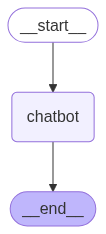

In [ ]:
try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

### Hw1

In [ ]:
# 定義 LangGraph 的 State 結構
class RAGState(TypedDict):
    query: str
    docs: List[Document]
    answer: str

In [ ]:
def retrieve_node(state: RAGState) -> RAGState:
    query = state["query"]
    # similarity_search 距離越小越相似
    docs = vectorstore.similarity_search(query, k=3)
    return {"query": query, "docs": docs, "answer": ""}

def generate_node(state: RAGState) -> RAGState:
    query, docs = state["query"], state["docs"]
    context = "\n".join([d.page_content for d in docs])
    prompt = (
        f"你是一個知識型助手，請根據以下內容回答問題：\n\n"
        f"內容：{context}\n\n"
        f"問題：{query}\n\n回答："
    )
    output = generator(prompt, max_new_tokens=200)[0]["generated_text"]
    return {"query": query, "docs": docs, "answer": output}

def direct_generate_node(state: RAGState) -> RAGState:
    query = state["query"]
    prompt = f"請回答以下問題：{query}\n\n回答："
    output = generator(prompt, max_new_tokens=200)[0]["generated_text"]
    return {"query": query, "docs": [], "answer": output}



In [ ]:
from langchain.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import Chroma
import torch
import torch.nn.functional as F

# 定義主題分類代表語句
category_representations = {
    "naruto": f"火影忍者的角色、忍術、劇情、歷代火影;他們包含{docs_text}",
    "general": "其他一般性的常識與問題"
}

# 向量化分類語句（只要做一次即可）
category_embeddings = {
    key: embedding_model.embed_query(text)
    for key, text in category_representations.items()
}

def route_by_query(state):
    query = state["query"]
    query_embedding = embedding_model.embed_query(query)

    # 計算 cosine similarity
    similarities = {
        label: F.cosine_similarity(
            torch.tensor(query_embedding),
            torch.tensor(embedding),
            dim=0
        ).item()
        for label, embedding in category_embeddings.items()
    }

    # 選擇最相近分類
    choice = max(similarities, key=similarities.get)
    print(f"跑到 → {choice}（相似度：{similarities[choice]:.4f}）")
    return choice


In [ ]:
# # 定義 Route Node（決定走哪條路）
# def route_by_query(state):
#     keywords = ["火影", "忍者", "歷代"]
#     query = state["query"]
#     choice = "naruto" if any(word in query for word in keywords) else "general"
#     print(f"跑到 → {choice}")
#     return choice

In [ ]:
from langchain_core.runnables import RunnableLambda
from langgraph.graph import StateGraph, END

# 建立 LangGraph 流程圖
graph_builder = StateGraph(RAGState)

graph_builder.set_entry_point("condition")
graph_builder.add_node("condition", RunnableLambda(lambda x: x))  # 進來就分流，不改變內容
graph_builder.add_node("retriever", RunnableLambda(retrieve_node))
graph_builder.add_node("generator", RunnableLambda(generate_node))
graph_builder.add_node("direct_generator", RunnableLambda(direct_generate_node))

# 設定條件分流
graph_builder.add_conditional_edges(
    source="condition",
    path=RunnableLambda(route_by_query),
    path_map={
        "naruto": "retriever",
        "general": "direct_generator",
    }
)

# 接下來的正常連接
graph_builder.add_edge("retriever", "generator")
graph_builder.add_edge("generator", END)
graph_builder.add_edge("direct_generator", END)

# 編譯 Graph
graph = graph_builder.compile()

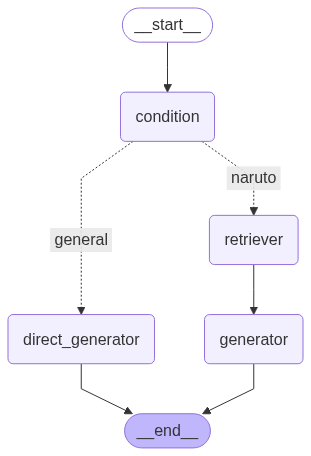

In [ ]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [ ]:
print("開始對話吧（輸入 q 結束）")

while True:
    user_input = input("使用者: ")
    if user_input.strip().lower() in ["q", "quit", "exit"]:
        print("掰啦！")
        break

    init_state: RAGState = {
        "query": user_input,
        "docs": [],
        "answer": ""
    }

    result = graph.invoke(init_state)
    raw_output = result["answer"]

    answer_text = raw_output.split("回答：")[-1].strip()
    print("回答：", answer_text)
    print("===" * 20, "\n")

開始對話吧（輸入 q 結束）
使用者: 春野櫻
跑到 → naruto（相似度：0.4136）
回答： 春野櫻是火影忍者世界中的人物，她是五代目火影千手綱手的徒弟。

使用者: q
掰啦！


# advance

改成能支援多輪問答（Multi-turn RAG），並能根據前面的query判斷問題。

> 請將 RAGState 加入 history 欄位，並在生成回答時，將歷史對話與當前問題一起組成 prompt。

> Hint：
```
class MultiTurnRAGState(TypedDict):  
    history: List[str]  
    query: str  
    docs: List[Document]  
    answer: str
```



In [ ]:
docs_text = """
火影代數	姓名	師傅	徒弟
初代	千手柱間	無明確記載	猿飛日斬、水戶門炎、轉寢小春
二代	千手扉間	千手柱間（兄長）	猿飛日斬、志村團藏、宇智波鏡等
三代	猿飛日斬	千手柱間、千手扉間	自來也、大蛇丸、千手綱手（傳說三忍）
四代	波風湊	自來也	旗木卡卡西、宇智波帶土、野原琳
五代	千手綱手	猿飛日斬	春野櫻、志乃等（主要為春野櫻）
六代	旗木卡卡西	波風湊	漩渦鳴人、宇智波佐助、春野櫻（第七班）
七代	漩渦鳴人	自來也、旗木卡卡西	木葉丸等（主要為木葉丸）
"""

In [ ]:
global_history: List[str] = []

print("開始對話吧（輸入 q 結束）")
while True:
    user_input = input("使用者: ")
    if user_input.strip().lower() in ["q", "quit", "exit"]:
        print("掰啦！")
        break

    state = {"history": global_history, "query": user_input}
    result = graph.invoke(state)

    answer = result["answer"].split("回答：")[-1].strip()
    print("AI 助理:", answer)
    print("===" * 60, "\n")

    global_history = result["history"]

開始對話吧（輸入 q 結束）
使用者: 第四代火影是誰?
route: cosine_sim = 0.8092
跑到 → retriever
retrieve combined query: '第四代火影是誰?'
AI 助理: 第四代火影是波風湊。

使用者: 他的師父是誰?
route: cosine_sim = 0.5529
跑到 → retriever
retrieve combined query: '第四代火影是誰?\n他的師父是誰?'
AI 助理: 第四代火影的師父是自來也。

使用者: 他的徒弟有哪些人?
route: cosine_sim = 0.6542
跑到 → retriever
retrieve combined query: '第四代火影是誰?\n他的師父是誰?\n他的徒弟有哪些人?'
AI 助理: 他的徒弟有以下人：旗木卡卡西、宇智波帶土、野原琳。

使用者: 相對論是他發明的嗎?
route: cosine_sim = 0.1118
跑到 → general
AI 助理: 相對論不是第四代火影所發明的。相對論是物理學家阿爾伯特·愛因斯坦在1905年提出的，他提出了廣義相對論，後人又提出狹義相對論。相對論主要是研究加速度和重力的關係，以及加速度和時間、空間的關係。

使用者: q
掰啦！
